
# Teste de Robustez a Deslocamento Temporal (Time Shift) - StackOverflow

Neste notebook, testaremos a **invariância a translação** do RoTHP.
A hipótese é que o RoTHP, por usar posições relativas, deve manter sua performance mesmo se deslocarmos todos os timestamps por um valor grande (ex: +100.000).
O THP tradicional (embedding absoluto) deve sofrer degradação ou instabilidade.

Dataset: **StackOverflow**
Shift: **+100.000** em todos os tempos.

**Melhorias incluídas:**
- Early Stopping (Patience = 5)
- Adaptive Learning Rate Scheduler
- Melhor logging


In [1]:

import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

project_root = '/Users/hugoramossoares/Sites/EasyTemporalPointProcess'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import Models
from easy_tpp.model.torch_model.torch_rothp import RoTHP
from easy_tpp.model.torch_model.torch_rothp_hybrid import RoTHPHybrid
from easy_tpp.model.torch_model.torch_thp import THP

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


In [2]:

# =============================================================================
# CARREGAR DATASET (StackOverflow via HuggingFace)
# =============================================================================
print("Carregando dataset 'easytpp/stackoverflow'...")
dataset = load_dataset("easytpp/stackoverflow")

train_data = dataset['train']
dev_data = dataset['validation']
test_data = dataset['test']

print(f"\nDataset StackOverflow carregado!")
print(f"Treino: {len(train_data)} sequências")
print(f"Dev:    {len(dev_data)} sequências")
print(f"Teste:  {len(test_data)} sequências")

# Verificar metadados do primeiro exemplo
sample = train_data[0]
print("\nExemplo de sequência (Original):")
print(f"Time starts: {sample['time_since_start'][:5]}...")
print(f"Dim Process: {sample['dim_process']}")


Carregando dataset 'easytpp/stackoverflow'...

Dataset StackOverflow carregado!
Treino: 1401 sequências
Dev:    401 sequências
Teste:  401 sequências

Exemplo de sequência (Original):
Time starts: [0.0, 0.0018310546875, 4.216796875, 4.6507568359375, 4.7021484375]...
Dim Process: 22


In [3]:

# =============================================================================
# PREPARAÇÃO DE BATCH COM TIME SHIFT
# =============================================================================

# CONSTANTE DE DESLOCAMENTO TEMPORAL
SHIFT_VAL = 100000.0 

def collate_fn_shifted(batch_list):
    """
    Converte lista de dicts para tensores e APLICA SHIFT no tempo absoluto.
    """
    time_seqs = []
    time_delta_seqs = []
    type_seqs = []
    
    max_len = 0
    for item in batch_list:
        ts = item['time_since_start']
        td = item['time_since_last_event']
        ev = item['type_event']
        
        if len(ts) > max_len:
            max_len = len(ts)
            
        # AQUI ESTÁ O SHIFT: Adicionamos a constante ao tempo absoluto
        ts_shifted = torch.tensor(ts, dtype=torch.float32) + SHIFT_VAL
        
        time_seqs.append(ts_shifted)
        time_delta_seqs.append(torch.tensor(td, dtype=torch.float32)) # Deltas não mudam!
        type_seqs.append(torch.tensor(ev, dtype=torch.long))

    batch_size = len(batch_list)
    
    pad_time = torch.zeros(batch_size, max_len)
    pad_delta = torch.zeros(batch_size, max_len)
    pad_type = torch.zeros(batch_size, max_len, dtype=torch.long)
    attention_mask = torch.zeros(batch_size, max_len, max_len)
    batch_non_pad_mask = torch.zeros(batch_size, max_len)
    
    for i in range(batch_size):
        l = len(time_seqs[i])
        pad_time[i, :l] = time_seqs[i]
        pad_delta[i, :l] = time_delta_seqs[i]
        pad_type[i, :l] = type_seqs[i]
        batch_non_pad_mask[i, :l] = 1
        
        causal_mask = torch.tril(torch.ones(l, l))
        attention_mask[i, :l, :l] = causal_mask

    return (pad_time, pad_delta, pad_type, batch_non_pad_mask, attention_mask)

print(f"Collate function configurada com SHIFT = {SHIFT_VAL}")


Collate function configurada com SHIFT = 100000.0


In [4]:

# =============================================================================
# CONFIGURAÇÃO DO MODELO COM EARLY STOPPING
# =============================================================================

class ModelConfig:
    def __init__(self, hidden_size=64, num_heads=4, num_layers=2):
        self.hidden_size = hidden_size
        self.time_emb_size = hidden_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_rate = 0.1
        self.use_ln = True
        
        # StackOverflow Specs
        self.num_event_types = 22     
        self.num_event_types_pad = 23 
        self.pad_token_id = 22
        
        self.loss_integral_num_sample_per_step = 20
        self.use_mc_samples = False
        self.gpu = -1
        self.thinning = None

def train_eval_loop(model_class, name, config, train_ds, test_ds, epochs=50, batch_size=32, lr=1e-3, patience=5):
    print(f"\n>>> Iniciando Treinamento SHIFTED: {name}")
    torch.manual_seed(42)
    model = model_class(config)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4) # Added weight decay
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
    
    history = []
    best_nll = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        total_events = 0
        
        indices = np.random.permutation(len(train_ds))
        max_batches = 200 # Limit batches per epoch for speed
        
        for i in range(0, len(indices), batch_size):
            if i // batch_size > max_batches: break
            
            batch_idx = indices[i:i+batch_size]
            batch_list = [train_ds[int(k)] for k in batch_idx]
            batch_data = collate_fn_shifted(batch_list)
            
            optimizer.zero_grad()
            loss, num_events = model.loglike_loss(batch_data)
            
            # Gradient clipping is crucial
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            total_events += num_events
            
        nll_train = total_loss / (total_events + 1e-9)
        
        # Validation
        model.eval()
        with torch.no_grad():
            test_subset = [test_ds[i] for i in range(min(500, len(test_ds)))]
            batch_test = collate_fn_shifted(test_subset)
            loss_test, num_test = model.loglike_loss(batch_test)
            nll_test = (loss_test / num_test).item()
        
        print(f"  Ep {epoch} | Train NLL: {nll_train:.4f} | Test NLL: {nll_test:.4f}")
        history.append(nll_test)
        
        # Scheduler Step
        scheduler.step(nll_test)
        
        # Early Stopping Check
        if nll_test < best_nll:
            best_nll = nll_test
            patience_counter = 0
            best_model_state = model.state_dict() # Save best model (in memory)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  >>> Early Stopping at Epoch {epoch}. Best NLL: {best_nll:.4f}")
                break
                
    return history


In [5]:

# =============================================================================
# EXECUÇÃO COMPARATIVA
# =============================================================================

config = ModelConfig(hidden_size=64, num_heads=4, num_layers=2)

# 1. RoTHP Original
hist_rothp = train_eval_loop(RoTHP, "RoTHP Original", config, train_data, test_data, epochs=100, patience=7)

# 2. RoTHP Híbrido
hist_hybrid = train_eval_loop(RoTHPHybrid, "RoTHP Hybrid", config, train_data, test_data, epochs=100, patience=7)

# 3. THP Tradicional
hist_thp = train_eval_loop(THP, "THP Tradicional", config, train_data, test_data, epochs=100, patience=5)



>>> Iniciando Treinamento SHIFTED: RoTHP Original


/Users/hugoramossoares/Sites/ebgeniusai/myenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  Ep 1 | Train NLL: 3.8430 | Test NLL: 2.1742
  Ep 2 | Train NLL: 0.9376 | Test NLL: -0.0994
  Ep 3 | Train NLL: -0.7947 | Test NLL: -1.1682
  Ep 4 | Train NLL: -1.5490 | Test NLL: -1.6392
  Ep 5 | Train NLL: -1.9644 | Test NLL: -2.0511
  Ep 6 | Train NLL: -2.2159 | Test NLL: -2.3542
  Ep 7 | Train NLL: -2.3118 | Test NLL: -2.4952
  Ep 8 | Train NLL: -2.7685 | Test NLL: -2.8484
  Ep 9 | Train NLL: -2.9791 | Test NLL: -3.0034
  Ep 10 | Train NLL: -3.3080 | Test NLL: -3.3152
  Ep 11 | Train NLL: -2.8515 | Test NLL: -3.3109
  Ep 12 | Train NLL: -0.9442 | Test NLL: -0.3869
  Ep 13 | Train NLL: -1.5747 | Test NLL: -2.0828
  Ep 14 | Train NLL: -1.8666 | Test NLL: -2.4616
  Ep 15 | Train NLL: -2.5283 | Test NLL: -2.6822
  Ep 16 | Train NLL: -2.7389 | Test NLL: -2.8502
  Ep 17 | Train NLL: -2.6615 | Test NLL: -2.9635
  >>> Early Stopping at Epoch 17. Best NLL: -3.3152

>>> Iniciando Treinamento SHIFTED: RoTHP Hybrid
  Ep 1 | Train NLL: 3.6238 | Test NLL: 1.9452
  Ep 2 | Train NLL: 0.5794 | Tes

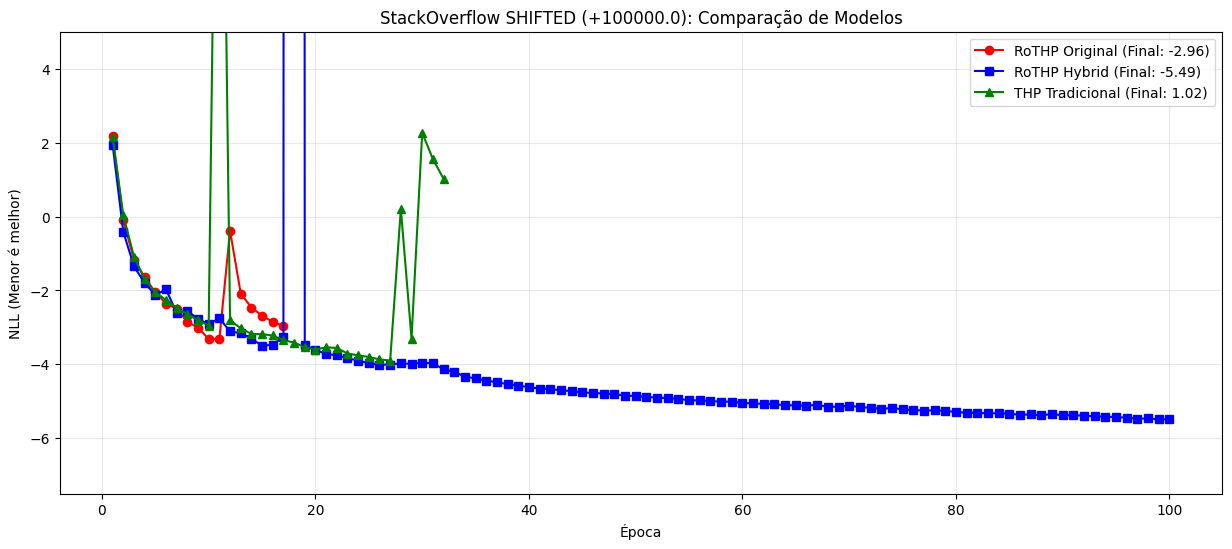

In [16]:
plt.figure(figsize=(15, 6))

# Função auxiliar para plotar dinamicamente
def plot_robust(hist, label, style):
    if hist and len(hist) > 0:
        epochs = range(1, len(hist) + 1)
        final_val = hist[-1]
        plt.plot(epochs, hist, style, label=f'{label} (Final: {final_val:.2f})')

# Plotar se as variáveis existirem
if 'hist_rothp' in locals(): plot_robust(hist_rothp, 'RoTHP Original', 'r-o')
if 'hist_hybrid' in locals(): plot_robust(hist_hybrid, 'RoTHP Hybrid', 'b-s')
if 'hist_thp' in locals(): plot_robust(hist_thp, 'THP Tradicional', 'g-^')

plt.xlabel('Época')
plt.ylabel('NLL (Menor é melhor)')
plt.title(f'StackOverflow SHIFTED (+{SHIFT_VAL}): Comparação de Modelos')
plt.legend()
plt.grid(True, alpha=0.3)
# Limit Y-axis to ignore extreme outliers
plt.ylim(top=5)
plt.ylim(bottom=-7.5)
plt.show()
